<a href="https://colab.research.google.com/github/deekshetharaja-svg/ML_LAB/blob/main/ex10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -q xgboost

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
from google.colab import files

uploaded = files.upload()

Saving vanet_traffic_data.csv to vanet_traffic_data (1).csv


In [7]:
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset Shape: (195714, 27)


,timestamp,road_segment_id,avg_speed_kmph,density_veh_per_km,avg_wait_time_s,occupancy_pct,flow_veh_per_hr,queue_length_veh,avg_accel_ms2,heading_deg,...,avg_comm_delay_ms,rssi_dbm,packet_loss_pct,speed_density_ratio,congestion_pressure,wireless_congestion_intensity,throughput_per_queued_vehicle,acceleration_directionality,weather_factor,label
0,2025-09-29T04:54:49,S090,43.38,24.78,20.57,39.85,1463.49,7.36,0.488,181.26,...,51.66,-60.28,5.56,1.7504,5.0977,1.6645,198.7510,88.4849,156.3778,Moderate
1,2025-09-30T06:15:38,S339,4.50,89.61,120.69,95.67,105.16,55.69,-1.047,0.78,...,204.45,-69.48,30.34,0.0502,108.1477,26.7853,1.8885,-0.8207,20.1982,Gridlock
2,2025-09-29T05:46:06,S167,45.68,29.45,17.79,42.26,1536.62,11.43,0.462,184.61,...,49.53,-58.90,4.60,1.5510,5.2396,1.3304,134.4387,85.2133,150.1454,Moderate
3,2025-09-28T21:15:29,S030,44.34,30.17,27.13,34.66,1486.33,9.63,0.550,174.62,...,49.64,-60.43,5.30,1.4700,8.1846,1.6631,154.2838,96.0502,149.7671,Moderate
4,2025-09-28T00:29:20,S261,66.86,5.30,7.86,12.45,1954.74,1.75,0.757,88.26,...,21.00,-55.23,0.30,12.6102,0.4169,0.0236,1117.7505,66.8219,259.8905,Free-flow


In [8]:
print("All columns in the dataset:")
for i, col in enumerate(df.columns):
    print(i, ":", col)

All columns in the dataset:
0 : timestamp
1 : road_segment_id
2 : avg_speed_kmph
3 : density_veh_per_km
4 : avg_wait_time_s
5 : occupancy_pct
6 : flow_veh_per_hr
7 : queue_length_veh
8 : avg_accel_ms2
9 : heading_deg
10 : signal_state_num
11 : incident_num
12 : temp_c
13 : visibility_km
14 : rain_intensity_mmph
15 : channel_busy_ratio_pct
16 : msg_rate_hz
17 : avg_comm_delay_ms
18 : rssi_dbm
19 : packet_loss_pct
20 : speed_density_ratio
21 : congestion_pressure
22 : wireless_congestion_intensity
23 : throughput_per_queued_vehicle
24 : acceleration_directionality
25 : weather_factor
26 : label


In [9]:
print("Possible congestion-related columns:")

for col in df.columns:
    if "congestion" in col.lower():
        print(col)

Possible congestion-related columns:
congestion_pressure
wireless_congestion_intensity


In [10]:
target_column = "congestion_class"

In [12]:
print("Congestion Classes:")
print(df["label"].value_counts())

print("\nUnique Classes:")
print(df["label"].unique())

Congestion Classes:
label
Free-flow    57812
Moderate     54018
Heavy        47440
Gridlock     36444
Name: count, dtype: int64

Unique Classes:
['Moderate' 'Gridlock' 'Free-flow' 'Heavy']


In [13]:
print("COLUMN NAMES")
print("=" * 50)

for i, col in enumerate(df.columns):
    print(i, ":", col)

print("\nCONGESTION RELATED COLUMNS")
print("=" * 50)

for col in df.columns:
    if "congestion" in col.lower():
        print(col)

COLUMN NAMES
0 : timestamp
1 : road_segment_id
2 : avg_speed_kmph
3 : density_veh_per_km
4 : avg_wait_time_s
5 : occupancy_pct
6 : flow_veh_per_hr
7 : queue_length_veh
8 : avg_accel_ms2
9 : heading_deg
10 : signal_state_num
11 : incident_num
12 : temp_c
13 : visibility_km
14 : rain_intensity_mmph
15 : channel_busy_ratio_pct
16 : msg_rate_hz
17 : avg_comm_delay_ms
18 : rssi_dbm
19 : packet_loss_pct
20 : speed_density_ratio
21 : congestion_pressure
22 : wireless_congestion_intensity
23 : throughput_per_queued_vehicle
24 : acceleration_directionality
25 : weather_factor
26 : label

CONGESTION RELATED COLUMNS
congestion_pressure
wireless_congestion_intensity


In [15]:
target = "label"
print("Target column:", target)
print("\nCongestion classes:")
print(df[target].value_counts())
print("\nUnique classes:")
print(df[target].unique())

Target column: label

Congestion classes:
label
Free-flow    57812
Moderate     54018
Heavy        47440
Gridlock     36444
Name: count, dtype: int64

Unique classes:
['Moderate' 'Gridlock' 'Free-flow' 'Heavy']


In [17]:
# ============================================
# TRAFFIC CONGESTION PREDICTION USING XGBOOST
# ============================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# Target column
target = "label"

# Remove rows with missing target
df = df.dropna(subset=[target]).copy()

# Separate input features and target
X = df.drop(columns=[target])
y = df[target].astype(str)

print("Dataset shape:", df.shape)
print("Target:", target)
print("Classes:", y.unique())

Dataset shape: (195714, 27)
Target: label
Classes: ['Moderate' 'Gridlock' 'Free-flow' 'Heavy']


In [18]:
# Convert timestamp into useful numerical features

if "timestamp" in X.columns:
    X["timestamp"] = pd.to_datetime(X["timestamp"], errors="coerce")

    X["hour"] = X["timestamp"].dt.hour
    X["day"] = X["timestamp"].dt.day
    X["month"] = X["timestamp"].dt.month
    X["dayofweek"] = X["timestamp"].dt.dayofweek

    X = X.drop(columns=["timestamp"])

print("Timestamp processed successfully!")

Timestamp processed successfully!


In [19]:
if "road_segment_id" in X.columns:
    X = X.drop(columns=["road_segment_id"])

print("Features remaining:")
print(X.columns.tolist())

Features remaining:
['avg_speed_kmph', 'density_veh_per_km', 'avg_wait_time_s', 'occupancy_pct', 'flow_veh_per_hr', 'queue_length_veh', 'avg_accel_ms2', 'heading_deg', 'signal_state_num', 'incident_num', 'temp_c', 'visibility_km', 'rain_intensity_mmph', 'channel_busy_ratio_pct', 'msg_rate_hz', 'avg_comm_delay_ms', 'rssi_dbm', 'packet_loss_pct', 'speed_density_ratio', 'congestion_pressure', 'wireless_congestion_intensity', 'throughput_per_queued_vehicle', 'acceleration_directionality', 'weather_factor', 'hour', 'day', 'month', 'dayofweek']


In [20]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Congestion Class Encoding:")

for number, label in enumerate(encoder.classes_):
    print(number, "=", label)

Congestion Class Encoding:
0 = Free-flow
1 = Gridlock
2 = Heavy
3 = Moderate


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 156571
Testing samples : 39143


In [22]:
model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss",
    n_jobs=-1
)

print("Training XGBoost...")
model.fit(X_train, y_train)

print("XGBoost training completed successfully!")

Training XGBoost...
XGBoost training completed successfully!


In [23]:
y_pred = model.predict(X_test)

print("Prediction completed!")

Prediction completed!


In [24]:
accuracy = accuracy_score(y_test, y_pred)

print("=" * 50)
print("TRAFFIC CONGESTION PREDICTION")
print("=" * 50)
print("Algorithm : XGBoost")
print(f"Accuracy  : {accuracy * 100:.2f}%")

TRAFFIC CONGESTION PREDICTION
Algorithm : XGBoost
Accuracy  : 99.06%


In [25]:
print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

Classification Report
              precision    recall  f1-score   support

   Free-flow       0.99      1.00      0.99     11562
    Gridlock       0.99      0.99      0.99      7289
       Heavy       0.99      0.99      0.99      9488
    Moderate       0.99      0.99      0.99     10804

    accuracy                           0.99     39143
   macro avg       0.99      0.99      0.99     39143
weighted avg       0.99      0.99      0.99     39143



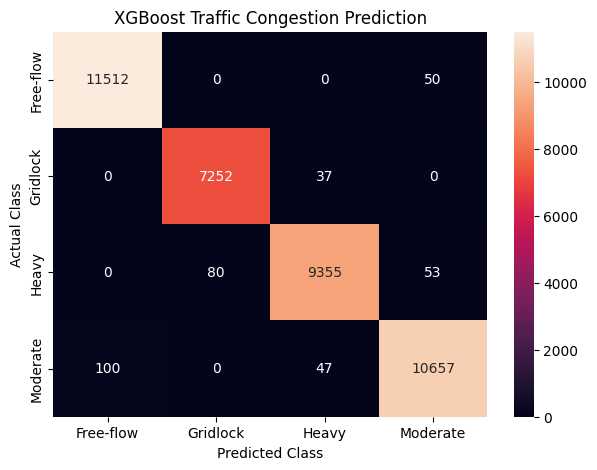

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("XGBoost Traffic Congestion Prediction")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [27]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(15))

                          Feature  Importance
7                     heading_deg    0.254683
12            rain_intensity_mmph    0.226204
22    acceleration_directionality    0.122503
15              avg_comm_delay_ms    0.112114
17                packet_loss_pct    0.078657
2                 avg_wait_time_s    0.072035
4                 flow_veh_per_hr    0.032465
21  throughput_per_queued_vehicle    0.023186
27                      dayofweek    0.020064
9                    incident_num    0.014651
13         channel_busy_ratio_pct    0.010149
1              density_veh_per_km    0.005575
0                  avg_speed_kmph    0.004478
8                signal_state_num    0.003934
16                       rssi_dbm    0.002754


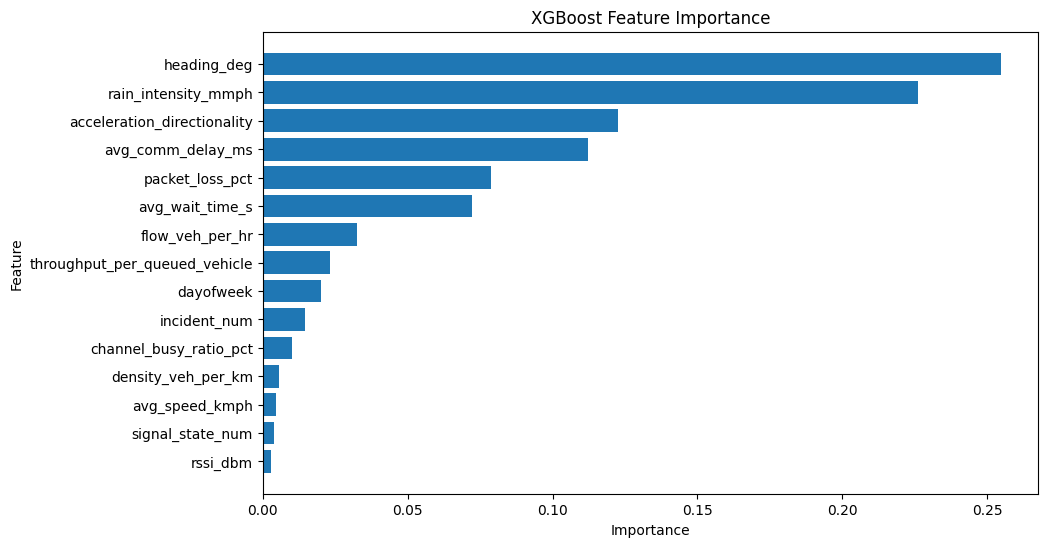

In [28]:
plt.figure(figsize=(10, 6))

top_features = importance.head(15)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()